In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
import zipfile

zip_ref = zipfile.ZipFile('/content/drive/MyDrive/mall customer data/archive.zip')
zip_ref.extractall('/content')
zip_ref.close()

In [92]:
customer_data = pd.read_csv('/content/Mall_Customers.csv')

In [93]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [94]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [95]:
customer_data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [96]:
customer_data.fillna(customer_data.mean(numeric_only=True), inplace=True)

In [97]:
customer_data.duplicated().sum()

np.int64(0)

In [98]:
customer_data.drop_duplicates(inplace=True)

In [99]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


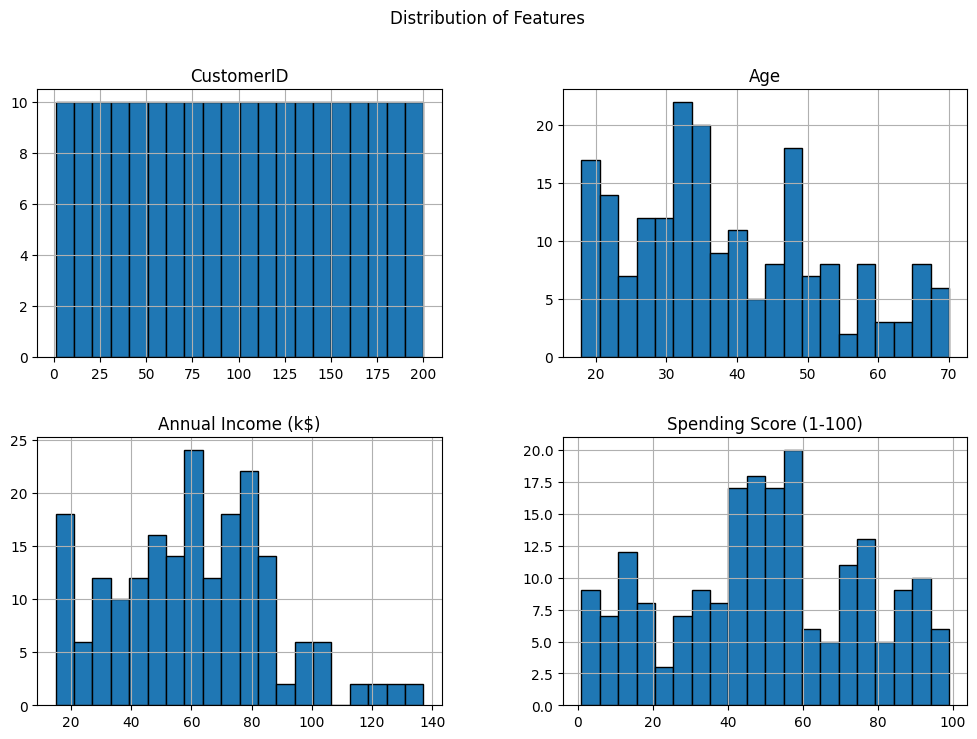

In [100]:
customer_data.hist(figsize=(12,8),
                   bins=20,
                   edgecolor='black')

plt.suptitle("Distribution of Features")
plt.show()

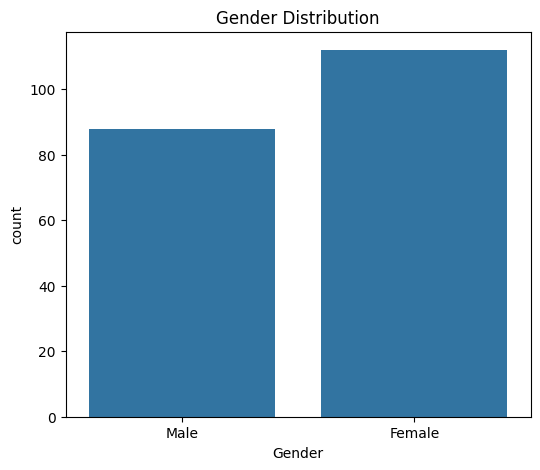

In [101]:
plt.figure(figsize=(6,5))

sns.countplot(data=customer_data,
              x='Gender')

plt.title("Gender Distribution")
plt.show()

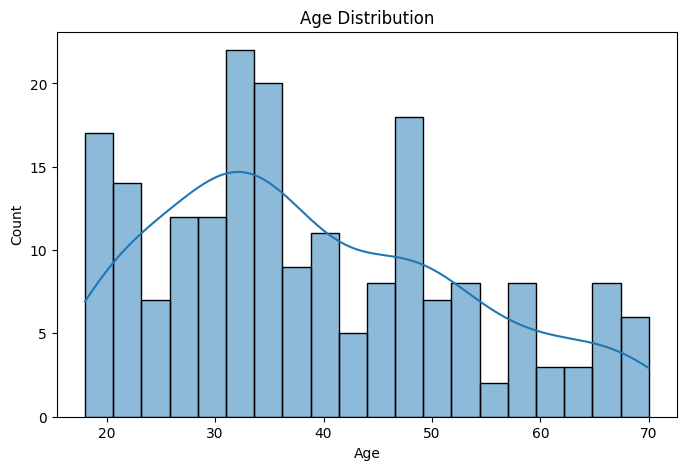

In [102]:
plt.figure(figsize=(8,5))

sns.histplot(customer_data['Age'],
             bins=20,
             kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

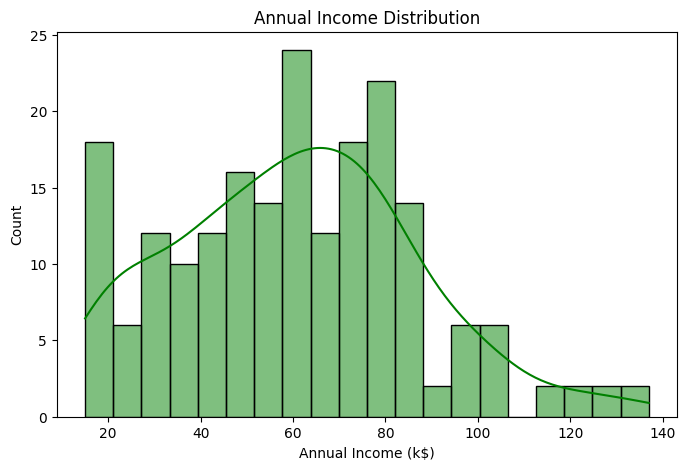

In [103]:
plt.figure(figsize=(8,5))

sns.histplot(customer_data['Annual Income (k$)'],
             bins=20,
             kde=True,
             color='green')

plt.title("Annual Income Distribution")
plt.show()

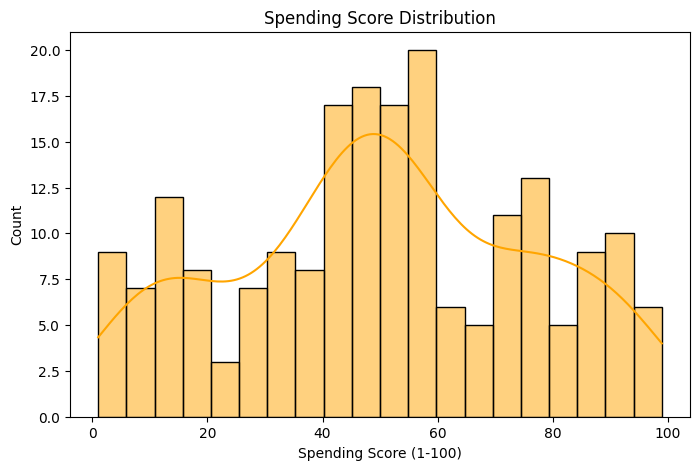

In [104]:
plt.figure(figsize=(8,5))

sns.histplot(customer_data['Spending Score (1-100)'],
             bins=20,
             kde=True,
             color='orange')

plt.title("Spending Score Distribution")
plt.show()

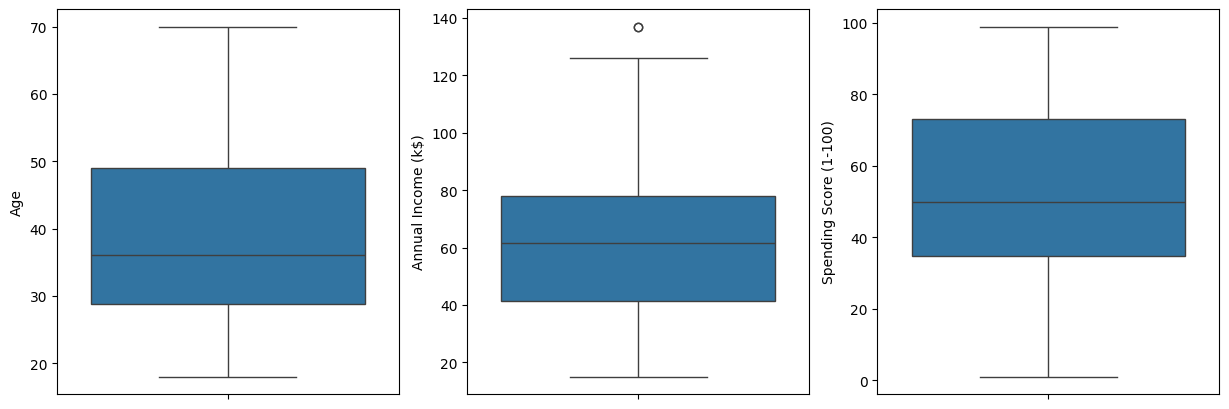

In [105]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=customer_data['Age'])

plt.subplot(1,3,2)
sns.boxplot(y=customer_data['Annual Income (k$)'])

plt.subplot(1,3,3)
sns.boxplot(y=customer_data['Spending Score (1-100)'])

plt.show()

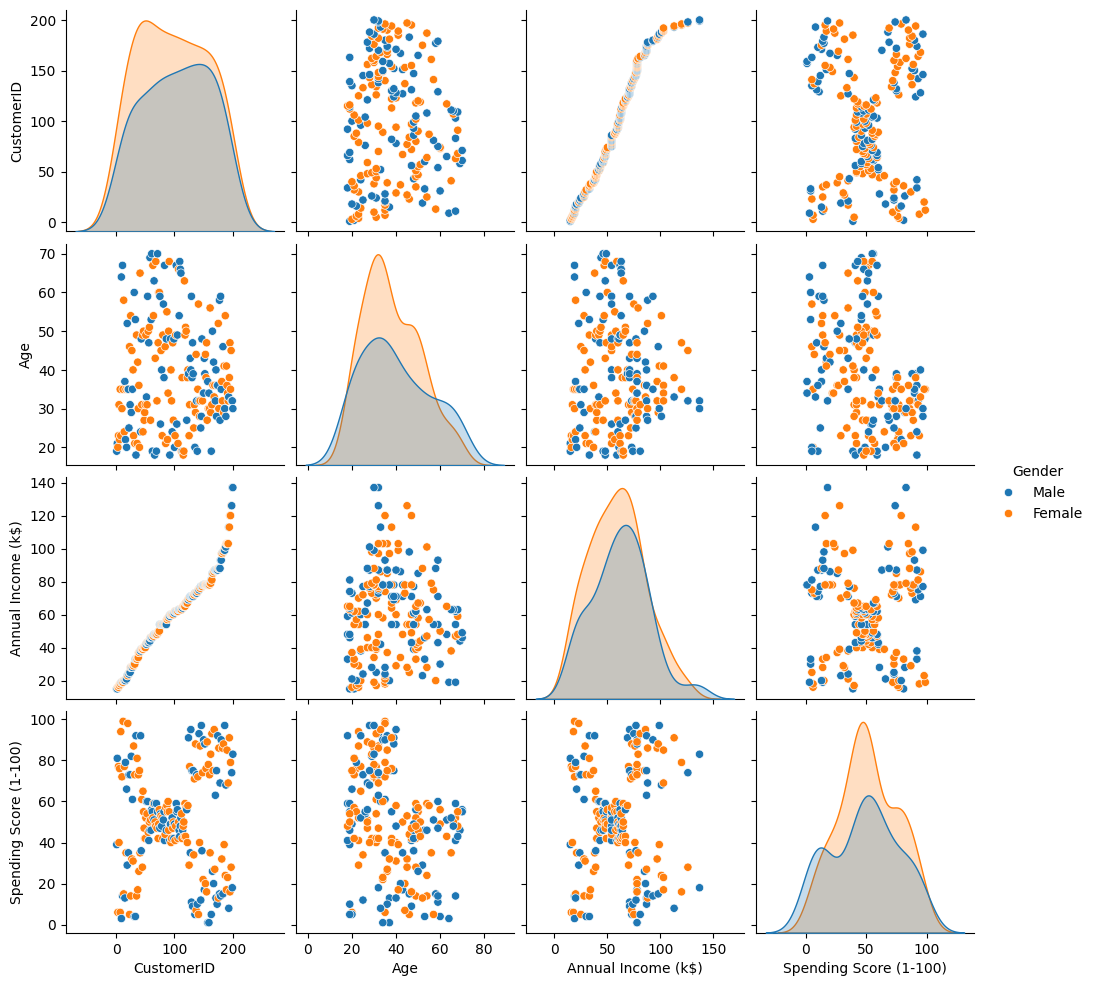

In [106]:
sns.pairplot(customer_data,
             hue='Gender')

plt.show()

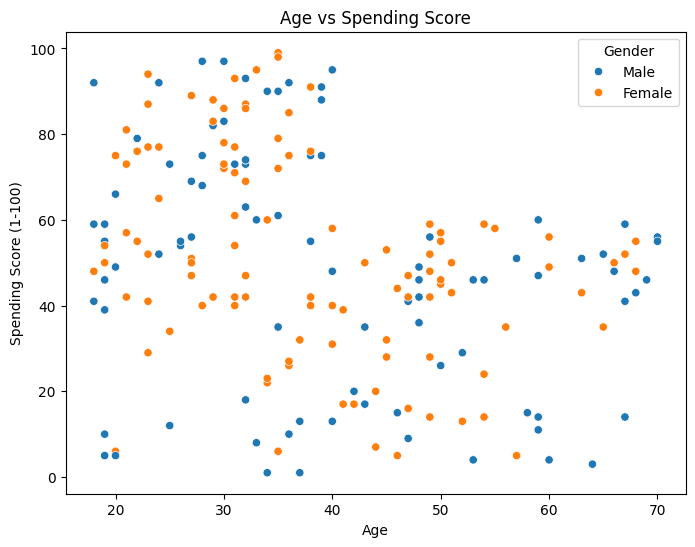

In [107]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=customer_data,
                x='Age',
                y='Spending Score (1-100)',
                hue='Gender')

plt.title("Age vs Spending Score")
plt.show()

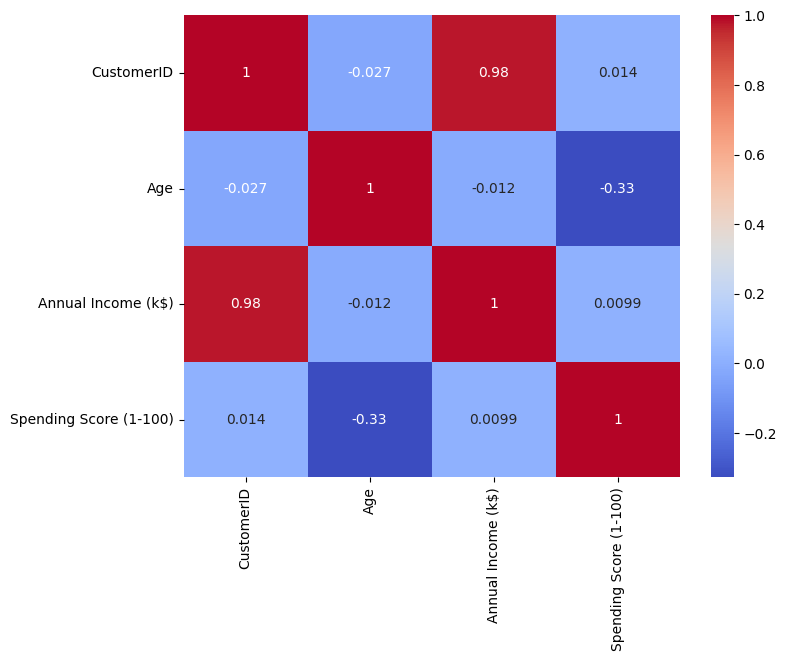

In [108]:
plt.figure(figsize=(8,6))
sns.heatmap(customer_data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [109]:
X = customer_data[['Annual Income (k$)',
                   'Spending Score (1-100)']].values

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [111]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    random_state=42)

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

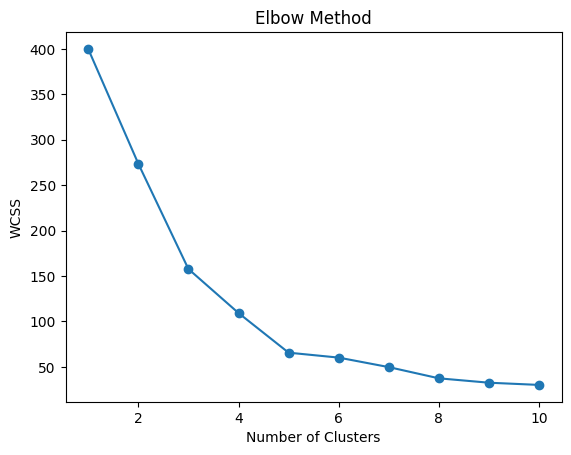

In [112]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [113]:
kmeans = KMeans(n_clusters=5,
                init='k-means++',
                random_state=42)

Y = kmeans.fit_predict(X_scaled)

In [114]:
customer_data['Cluster'] = Y

In [115]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


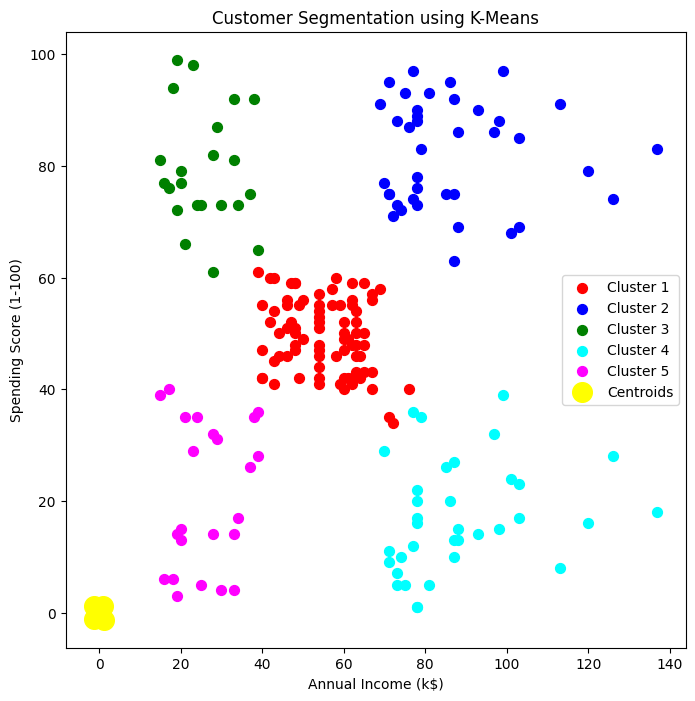

In [116]:
plt.figure(figsize=(8,8))

plt.scatter(X[Y==0,0], X[Y==0,1],
            s=50, c='red', label='Cluster 1')

plt.scatter(X[Y==1,0], X[Y==1,1],
            s=50, c='blue', label='Cluster 2')

plt.scatter(X[Y==2,0], X[Y==2,1],
            s=50, c='green', label='Cluster 3')

plt.scatter(X[Y==3,0], X[Y==3,1],
            s=50, c='cyan', label='Cluster 4')

plt.scatter(X[Y==4,0], X[Y==4,1],
            s=50, c='magenta', label='Cluster 5')

# Centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200,
            c='yellow',
            label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.show()

In [117]:
customer_data['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [118]:
customer_data.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [119]:
customer_data.to_csv('Customer_Segmentation_Result.csv',
                     index=False)

In [120]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

print("Model Evaluation Results")
print("-"*30)

print("Silhouette Score:",
      silhouette_score(X_scaled, Y))

print("Davies-Bouldin Index:",
      davies_bouldin_score(X_scaled, Y))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(X_scaled, Y))

print("WCSS:",
      kmeans.inertia_)

Model Evaluation Results
------------------------------
Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352
Calinski-Harabasz Score: 248.64932001536357
WCSS: 65.56840815571681
